In [ ]:
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt
import sys
import yaml

from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
%matplotlib widget 

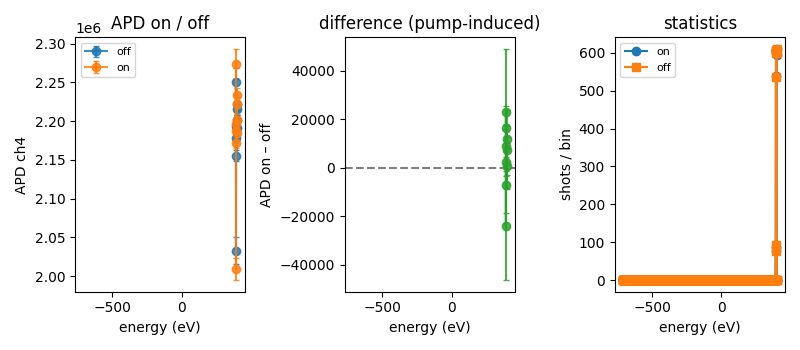

In [9]:
def avg_apd_vs_energy(runs, exp, base_folder, cfg,
                      mono_calib_path='../mono_calib.yml',
                      apd_channel=8, common_roi=(50, 200), common_bg=(0, 45),
                      ebin_width=1.0):
    """APD-vs-energy averaged across runs, separated by laser on/off (mirrors plot_svls1D)."""
    from chemrixs.utils import mono_energy, get_premirror_pitch
    from scipy import stats as st

    all_E, all_A, all_on, all_off = [], [], [], []
    for run in runs:
        fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
        mc = next((np.asarray(r)[2:4] for r in cfg['mono_calib'] if run > r[0] and run < r[1]), None)
        if mc is None:
            print(f'skipping run {run}: no mono_calib row'); continue

        with h5py.File(fname, 'r') as h5:
            g = h5['intg/axis_svls']
            apd_wf  = g['det_crix_w8_sum_full_area'][:]
            count   = g['count'][:].squeeze()
            monoenc = g['mono_hrencoder_sum_value'][:].squeeze()
            evc     = g['timing_sum_eventcodes'][:]
            try:
                ek, ea = cfg['epics']['key'], cfg['epics']['attr']['MONO_premirror_pitch']
                premirror = get_premirror_pitch(h5[f'/{ek}/{ea}'][:, 1])
            except Exception:
                premirror = 144506

        ch  = apd_channel - 1
        bg  = apd_wf[:, ch, common_bg[0]:common_bg[1]].mean(-1, keepdims=True)
        bgf = apd_wf[:, ch, :] - bg
        apd = np.nansum(np.abs(bgf[:, common_roi[0]:common_roi[1]]), axis=1)

        pitchG = np.polyval(mc, monoenc / count)
        eV     = mono_energy(pitchG, premirror, fname=mono_calib_path)

        mode_c = st.mode(count, keepdims=False)[0]
        cmask  = (count > mode_c-1) & (count < mode_c+1)
        on  = (evc[:, cfg['evc'][True]]  / mode_c > 0.5) & cmask
        off = (evc[:, cfg['evc'][False]] / mode_c > 0.5) & cmask

        all_E.append(eV); all_A.append(apd)
        all_on.append(on); all_off.append(off)

    E, A   = np.concatenate(all_E), np.concatenate(all_A)
    on_m   = np.concatenate(all_on)
    off_m  = np.concatenate(all_off)

    ebins = np.arange(np.floor(np.nanmin(E)), np.ceil(np.nanmax(E)) + 1, ebin_width)
    ecen  = 0.5 * (ebins[:-1] + ebins[1:])
    idx   = np.digitize(E, ebins)

    def bin_with(mask):
        n   = np.array([((idx==i+1) & mask).sum() for i in range(len(ecen))])
        mu  = np.array([np.nanmean(A[(idx==i+1) & mask]) if n[i] > 5 else np.nan for i in range(len(ecen))])
        sem = np.array([np.nanstd(A[(idx==i+1) & mask])/np.sqrt(n[i]) if n[i] > 5 else np.nan
                        for i in range(len(ecen))])
        return n, mu, sem

    n_on, mu_on, sem_on    = bin_with(on_m)
    n_off, mu_off, sem_off = bin_with(off_m)
    return dict(ecen=ecen,
                on_mean=mu_on,   on_sem=sem_on,   n_on=n_on,
                off_mean=mu_off, off_sem=sem_off, n_off=n_off)


# ---- usage ----



# --- config ---
base = '/sdf/data/lcls/ds/rix/'
exp  = 'rix101331225'
runs = [145]
run  = runs[0]
fyaml_path = '../roi_inputTT.yml'         # swap to ferufe/roi_input_ferufe.yml if needed
n_show     = -1                       # subsample for speed
fname = f'{base}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
# fname = f'{base}/{exp}/hdf5/smalldata/run140_th100_tha480/{exp}_Run{run:04d}.h5' 


with open(fyaml_path) as f:
    cfg = yaml.safe_load(f)
res  = avg_apd_vs_energy(runs, 'rix101331225', '/sdf/data/lcls/ds/rix/', cfg, apd_channel=8)

fig, ax = plt.subplots(1, 3, figsize=(8, 3.5), sharex=True)
ax[0].errorbar(res['ecen'], res['off_mean'], yerr=res['off_sem'], fmt='o-',
               color='tab:blue',   label='off', capsize=2, alpha=0.85)
ax[0].errorbar(res['ecen'], res['on_mean'],  yerr=res['on_sem'],  fmt='o-',
               color='tab:orange', label='on',  capsize=2, alpha=0.85)
ax[0].set_xlabel('energy (eV)'); ax[0].set_ylabel(f'APD ch{4}')
ax[0].set_title('APD on / off'); ax[0].legend(fontsize=8)

diff     = res['on_mean'] - res['off_mean']
diff_err = np.sqrt(res['on_sem']**2 + res['off_sem']**2)
ax[1].errorbar(res['ecen'], diff, yerr=diff_err, fmt='o-', color='tab:green', capsize=2, alpha=0.85)
ax[1].axhline(0, ls='--', color='k', alpha=0.5)
ax[1].set_xlabel('energy (eV)'); ax[1].set_ylabel('APD on – off'); ax[1].set_title('difference (pump-induced)')

ax[2].plot(res['ecen'], res['n_on'],  'o-', label='on')
ax[2].plot(res['ecen'], res['n_off'], 's-', label='off')
ax[2].set_xlabel('energy (eV)'); ax[2].set_ylabel('shots / bin'); ax[2].set_title('statistics'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

/sdf/data/lcls/ds/rix//rix101331225/hdf5/smalldata/rix101331225_Run0145.h5
<KeysViewHDF5 ['c_atmopal_calib', 'c_piranha_calib', 'det_crix_w8_calib', 'det_rix_fim0_calib', 'det_rix_fim1_calib']>
<KeysViewHDF5 ['andor_dir', 'andor_vls', 'axis_svls', 'timestamp']>
fim0 shape: (16311, 8, 256), fim1 shape: (16311, 8, 256)


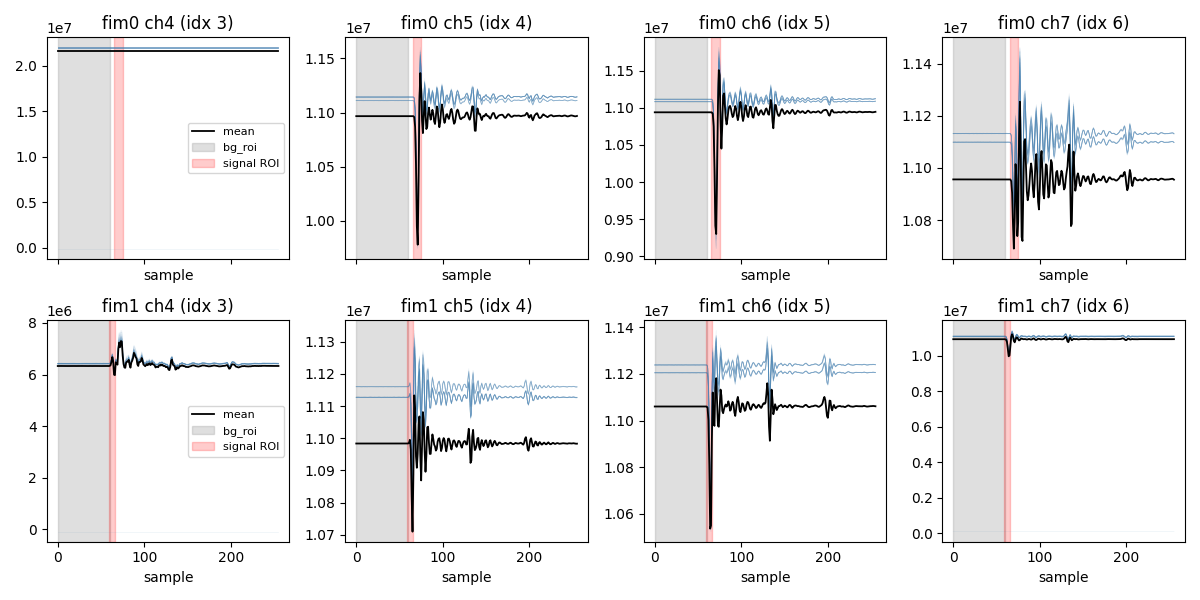

In [10]:

print(fname)

fim0_cfg = cfg['fim0']; fim1_cfg = cfg['fim1']

with h5py.File(fname, 'r') as h5:
    print(h5['Sums'].keys())
    print(h5['intg'].keys())
    fim0_wf = h5['intg']['axis_svls']['det_rix_fim0_sum_full_area'][:n_show]   # (shots, channels, samples)
    fim1_wf = h5['intg']['axis_svls']['det_rix_fim1_sum_full_area'][:n_show]
    print(f'fim0 shape: {fim0_wf.shape}, fim1 shape: {fim1_wf.shape}')



# --- plot: mean ± std per channel, with bg_roi (gray) + signal ROI (red) overlaid ---
fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=True)
nsamp = fim0_wf.shape[-1]; x = np.arange(nsamp)
rng = np.random.default_rng(0)

for det_name, wf, det_cfg, axrow in [('fim0', fim0_wf, fim0_cfg, axes[0]),
                                      ('fim1', fim1_wf, fim1_cfg, axes[1])]:
    channels, roi, bg_roi = det_cfg['channels'], det_cfg['roi'], det_cfg['bg_roi']
    for i, c in enumerate(channels):
        ax = axrow[i]; ch = c - 1   # yaml is 1-indexed
        m  = wf[:, ch, :].mean(0); s = wf[:, ch, :].std(0)
        # individual shots (faint)
        for j in rng.choice(wf.shape[0], 30, replace=False):
            ax.plot(x, wf[j, ch, :], color='steelblue', alpha=0.1, lw=0.5)
        ax.plot(x, m, 'k', lw=1.3, label='mean')
        # ax.fill_between(x, m-s, m+s, color='k', alpha=0.15, label='±1σ')
        ax.axvspan(bg_roi[0], bg_roi[1], color='gray', alpha=0.25, label='bg_roi')
        ax.axvspan(roi[i][0], roi[i][1], color='red',  alpha=0.20, label='signal ROI')
        ax.set_title(f'{det_name} ch{c} (idx {ch})'); ax.set_xlabel('sample')
        if i == 0: ax.legend(fontsize=8, loc='best')
plt.tight_layout(); plt.show()

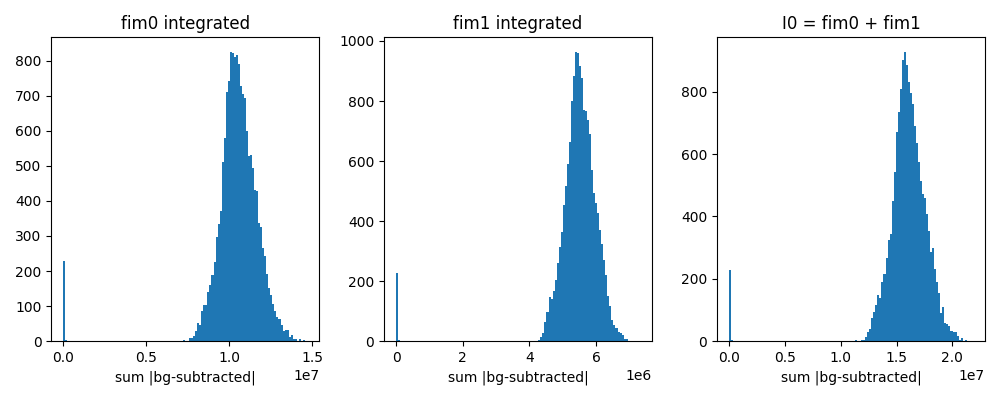

I0:  median=1.6e+07, 5%/95%=1.35e+07/1.86e+07, frac(I0<=0)=1.19%


In [11]:
def integrate_fim(wf, channels, roi, bg_roi):
    """Mirror chemrixs.utils.sumchan_helper 3D path."""
    bg  = wf[..., bg_roi[0]:bg_roi[1]].mean(axis=-1)
    bgf = wf - bg[..., None]
    out = np.zeros(wf.shape[0])
    for i, c in enumerate(channels):
        out += np.nansum(np.abs(bgf[:, c-1, roi[i][0]:roi[i][1]]), axis=1)
    return out

fim0_int = integrate_fim(fim0_wf, **fim0_cfg)
fim1_int = integrate_fim(fim1_wf, **fim1_cfg)
I0 = fim0_int + fim1_int

fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].hist(fim0_int, bins=120); ax[0].set_title('fim0 integrated')
ax[1].hist(fim1_int, bins=120); ax[1].set_title('fim1 integrated')
ax[2].hist(I0,       bins=120); ax[2].set_title('I0 = fim0 + fim1')
for a in ax: a.set_xlabel('sum |bg-subtracted|')
plt.tight_layout(); plt.show()

print(f'I0:  median={np.median(I0):.3g}, '
      f'5%/95%={np.percentile(I0,5):.3g}/{np.percentile(I0,95):.3g}, '
      f'frac(I0<=0)={(I0<=0).mean()*100:.2f}%')

In [12]:
print(f'{"det":<6} {"ch":<4} {"peak_in_ROI":<15} {"peak_idx mean±std":<22} {"ROI":<14} {"bg_std":<10}')
for det_name, wf, det_cfg in [('fim0', fim0_wf, fim0_cfg), ('fim1', fim1_wf, fim1_cfg)]:
    for i, c in enumerate(det_cfg['channels']):
        ch = c - 1
        roi    = det_cfg['roi'][i]; bg_roi = det_cfg['bg_roi']
        bg     = wf[:, ch, bg_roi[0]:bg_roi[1]].mean(-1, keepdims=True)
        bgf    = np.abs(wf[:, ch, :] - bg)
        peak   = bgf.argmax(-1)
        in_roi = ((peak >= roi[0]) & (peak <= roi[1])).mean() * 100
        bg_std = wf[:, ch, bg_roi[0]:bg_roi[1]].std(-1).mean()
        print(f'{det_name:<6} {c:<4} {in_roi:>6.2f}%        '
              f'{peak.mean():>5.1f} ± {peak.std():>4.1f}        '
              f'[{roi[0]},{roi[1]}]    {bg_std:>8.2f}')

det    ch   peak_in_ROI     peak_idx mean±std      ROI            bg_std    
fim0   4      0.00%          0.0 ±  0.0        [65,75]        0.00
fim0   5     98.80%         70.2 ±  7.8        [65,75]      313.32
fim0   6     98.80%         70.2 ±  7.8        [65,75]      248.97
fim0   7     23.98%         74.4 ±  8.7        [65,75]      286.97
fim1   4      0.01%         72.2 ±  8.0        [59,66]     1721.92
fim1   5     98.81%         64.2 ±  7.0        [59,66]      297.71
fim1   6     98.80%         63.3 ±  6.9        [59,66]      333.22
fim1   7     98.80%         63.2 ±  6.9        [59,66]      312.73


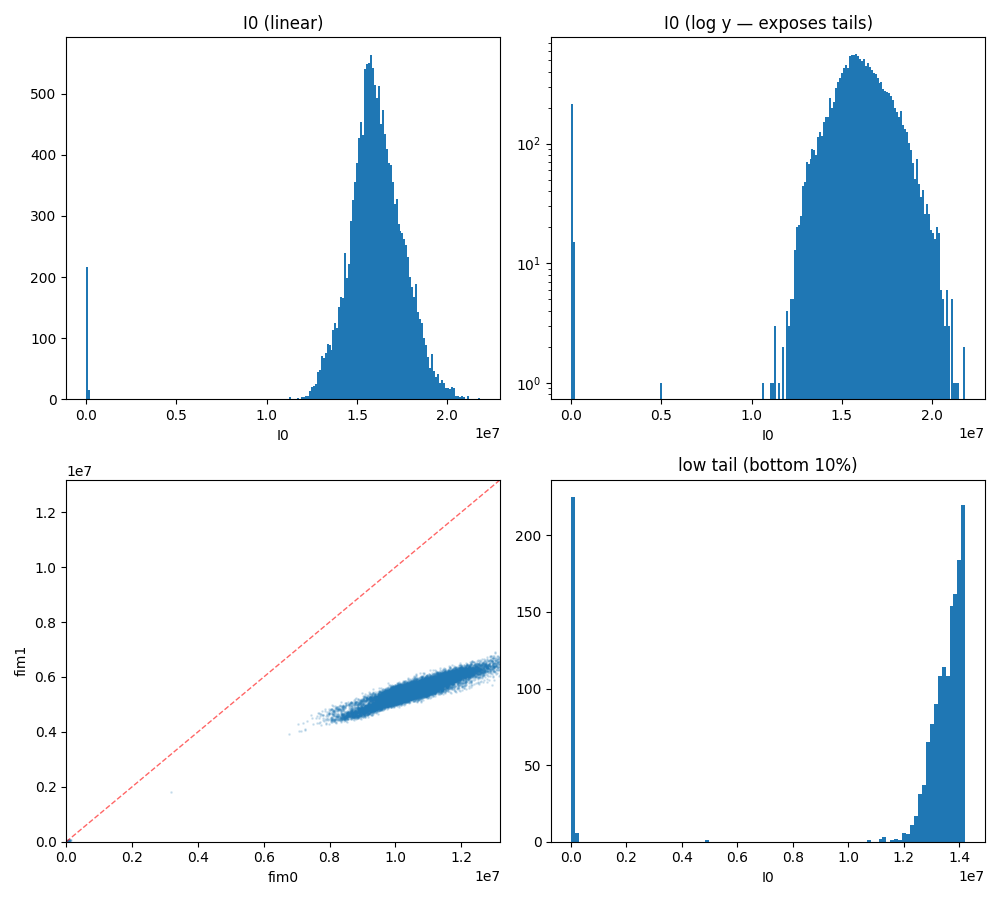

fim0: min=0 | p0.1=0 p1=0 p5=8.8e+06 | med=1.05e+07 | p95=1.23e+07 p99=1.32e+07 p99.9=1.4e+07 | max=1.47e+07
       frac(<=0)=1.189%  frac(<10%·median)=1.416%
fim1: min=0 | p0.1=0 p1=0 p5=4.72e+06 | med=5.5e+06 | p95=6.26e+06 p99=6.56e+06 p99.9=6.86e+06 | max=7.31e+06
       frac(<=0)=1.189%  frac(<10%·median)=1.416%
  I0: min=0 | p0.1=0 p1=0 p5=1.35e+07 | med=1.6e+07 | p95=1.86e+07 p99=1.97e+07 p99.9=2.08e+07 | max=2.18e+07
       frac(<=0)=1.189%  frac(<10%·median)=1.416%


In [13]:
# === Step 2: is I0 too high / too low? ===
fig, ax = plt.subplots(2, 2, figsize=(10, 9))

ax[0,0].hist(I0, bins=200)
ax[0,0].set_title('I0 (linear)'); ax[0,0].set_xlabel('I0')

ax[0,1].hist(I0, bins=200); ax[0,1].set_yscale('log')
ax[0,1].set_title('I0 (log y — exposes tails)'); ax[0,1].set_xlabel('I0')

ax[1,0].plot(fim0_int, fim1_int, '.', ms=2, alpha=0.15)
lim = [0, np.percentile(np.r_[fim0_int, fim1_int], 99.5)]
ax[1,0].plot(lim, lim, 'r--', lw=1, alpha=0.6)
ax[1,0].set_xlim(lim); ax[1,0].set_ylim(lim)
ax[1,0].set_xlabel('fim0'); ax[1,0].set_ylabel('fim1')
# ax[1,0].set_title('fim0 vs fim1 (off-diagonal = one FIM glitched)')

ax[1,1].hist(I0[I0 < np.percentile(I0, 10)], bins=100)
ax[1,1].set_title('low tail (bottom 10%)'); ax[1,1].set_xlabel('I0')
plt.tight_layout(); plt.show()

for name, arr in [('fim0', fim0_int), ('fim1', fim1_int), ('I0', I0)]:
    p = np.percentile(arr, [0.1, 1, 5, 50, 95, 99, 99.9])
    print(f'{name:>4}: min={arr.min():.3g} | p0.1={p[0]:.3g} p1={p[1]:.3g} '
          f'p5={p[2]:.3g} | med={p[3]:.3g} | p95={p[4]:.3g} p99={p[5]:.3g} '
          f'p99.9={p[6]:.3g} | max={arr.max():.3g}')
    print(f'       frac(<=0)={100*(arr<=0).mean():.3f}%  '
          f'frac(<10%·median)={100*(arr<0.1*p[3]).mean():.3f}%')

In [14]:
from scipy import stats as st

def integrate_fim(wf, channels, roi, bg_roi):
    """Same 3D integration as sumchan_helper, on the shot-summed integrating waveform."""
    bg  = wf[..., bg_roi[0]:bg_roi[1]].mean(axis=-1)
    bgf = wf - bg[..., None]
    out = np.zeros(wf.shape[0])
    for i, c in enumerate(channels):
        out += np.nansum(np.abs(bgf[:, c-1, roi[i][0]:roi[i][1]]), axis=1)
    return out

# I0 from the integrating FIM waveforms you already validated
fim0_i = integrate_fim(fim0_wf, **fim0_cfg)
fim1_i = integrate_fim(fim1_wf, **fim1_cfg)
I0_i   = fim0_i + fim1_i

# SVLS + alignment arrays — SAME [:n_show] slice to match the FIMs
with h5py.File(fname, 'r') as h5:
    g = h5['intg']['axis_svls']
    svls    = g['droplet_dense_curve_corr_pj_ax_1_data'][:n_show]
    count   = g['count'][:n_show].squeeze()
    monoenc = g['mono_hrencoder_sum_value'][:n_show].squeeze()
    evc     = g['timing_sum_eventcodes'][:n_show]
    try:    apd_wf = g['det_crix_w8_sum_full_area'][:n_show]   # optional cross-check
    except Exception: apd_wf = None

svls_sum = np.nansum(svls.reshape(svls.shape[0], -1), axis=1)   # per-frame SVLS total
mono_pxy = monoenc / count                                      # uncalibrated energy axis

mode_c = st.mode(count, keepdims=False)[0]
cmask  = (count > mode_c-1) & (count < mode_c+1)
on     = (evc[:, cfg['evc'][True]]  / mode_c > 0.5)
off    = (evc[:, cfg['evc'][False]] / mode_c > 0.5)

apd_i = None
if apd_wf is not None and apd_wf.ndim == 3 and 'apd' in cfg:
    try: apd_i = integrate_fim(apd_wf, **cfg['apd'])
    except Exception as ex: print('APD integ skipped:', ex)

print(f'frames={len(count)}  countmask-kept={cmask.sum()}  on={on.sum()}  off={off.sum()}')
print(f'I0_i median={np.median(I0_i[cmask]):.3g}  svls_sum median={np.median(svls_sum[cmask]):.3g}')
print(f'shapes  I0_i={I0_i.shape}  svls_sum={svls_sum.shape}  mono={mono_pxy.shape}  '
      f'(all must match {n_show})')

frames=16311  countmask-kept=8660  on=8039  off=8040
I0_i median=1.6e+07  svls_sum median=1.29e+03
shapes  I0_i=(16311,)  svls_sum=(16311,)  mono=(16311,)  (all must match -1)


apd_wf shape: (16311, 8, 256)


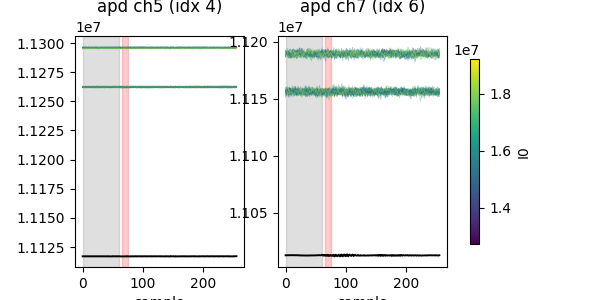

In [15]:
apd_cfg = cfg['apd']
with h5py.File(fname, 'r') as h5:
    apd_wf = h5['intg']['axis_svls']['det_crix_w8_sum_full_area'][:n_show]
print(f'apd_wf shape: {apd_wf.shape}')   # expect (frames, channels, samples)

channels, roi, bg_roi = apd_cfg['channels'], apd_cfg['roi'], apd_cfg['bg_roi']
nch, nsamp = len(channels), apd_wf.shape[-1]; x = np.arange(nsamp)

norm = plt.Normalize(np.percentile(I0_i, 2), np.percentile(I0_i, 98))
cmap = plt.cm.viridis
rng  = np.random.default_rng(0)
pick = rng.choice(apd_wf.shape[0], 60, replace=False)

ncol = min(nch, 4); nrow = int(np.ceil(nch/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3*ncol, 3*nrow), sharex=True, squeeze=False)
for i, c in enumerate(channels):
    ax = axes[i//ncol][i%ncol]; ch = c-1
    for j in pick:
        ax.plot(x, apd_wf[j, ch, :], color=cmap(norm(I0_i[j])), alpha=0.35, lw=0.6)
    ax.plot(x, apd_wf[:, ch, :].mean(0), 'k', lw=1.4)
    ax.axvspan(bg_roi[0], bg_roi[1], color='gray', alpha=0.25)
    if i < len(roi): ax.axvspan(roi[i][0], roi[i][1], color='red', alpha=0.20)
    ax.set_title(f'apd ch{c} (idx {ch})'); ax.set_xlabel('sample')
for k in range(nch, nrow*ncol): axes[k//ncol][k%ncol].axis('off')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label='I0', shrink=0.8)
plt.show()

In [16]:
print(f'{"ch":<4}{"peak_in_ROI":<14}{"sig_ampl":<12}{"bg_std":<12}{"S/N":<8}{"r(ROIsum,I0)":<14}')
for i, c in enumerate(channels):
    ch = c-1; r = roi[i] if i < len(roi) else roi[0]
    bg  = apd_wf[:, ch, bg_roi[0]:bg_roi[1]].mean(-1, keepdims=True)
    bgf = apd_wf[:, ch, :] - bg
    sig_ampl = np.abs(bgf[:, r[0]:r[1]]).mean()
    bg_std   = apd_wf[:, ch, bg_roi[0]:bg_roi[1]].std(-1).mean()
    peak     = np.abs(bgf).argmax(-1)
    in_roi   = ((peak >= r[0]) & (peak <= r[1])).mean() * 100
    roisum   = np.nansum(np.abs(bgf[:, r[0]:r[1]]), axis=1)
    rr       = np.corrcoef(roisum, I0_i)[0, 1]
    print(f'{c:<4}{in_roi:<14.1f}{sig_ampl:<12.3g}{bg_std:<12.3g}{sig_ampl/bg_std:<8.2f}{rr:<14.3f}')

ch  peak_in_ROI   sig_ampl    bg_std      S/N     r(ROIsum,I0)  
5   8.8           133         133         1.00    0.279         
7   5.1           1.48e+03    1.74e+03    0.85    0.259         


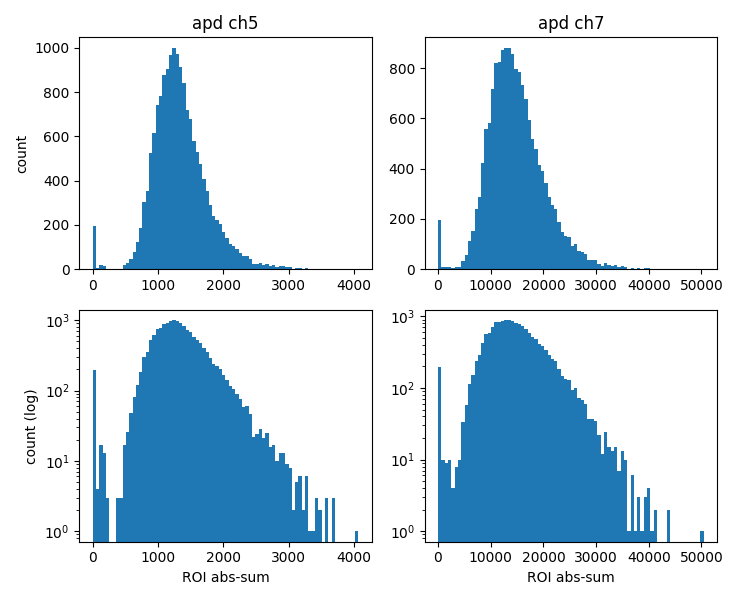

ch  med        p1         p99        CV      r_vs_I0   
5   1.29e+03   0          2.59e+03   0.318   0.279     
7   1.42e+04   0          3.02e+04   0.363   0.259     


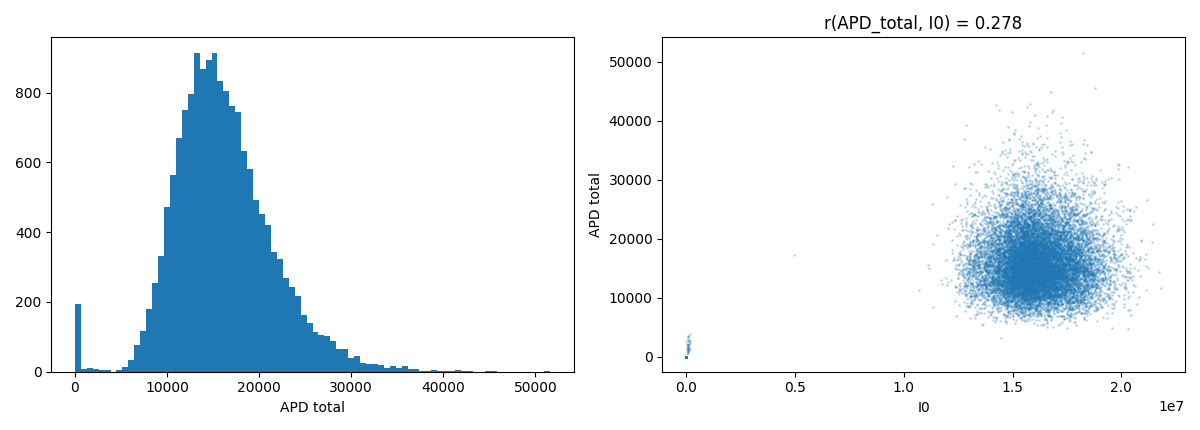


cross-channel correlation:
     ch5       ch7     
ch5  +1.000    +0.122  
ch7  +0.122    +1.000  


In [17]:
# per-channel integrals (same ROI as cell B)
apd_per_ch = {}
for i, c in enumerate(channels):
    ch = c-1; r = roi[i] if i < len(roi) else roi[0]
    bg  = apd_wf[:, ch, bg_roi[0]:bg_roi[1]].mean(-1, keepdims=True)
    bgf = apd_wf[:, ch, :] - bg
    apd_per_ch[c] = np.nansum(np.abs(bgf[:, r[0]:r[1]]), axis=1)

# histograms (linear + log y) — squeeze=False keeps axes 2D for any nch
nch = len(channels)
fig, axes = plt.subplots(2, nch, figsize=(max(3.7*nch, 5), 6), squeeze=False)
for col, c in enumerate(channels):
    arr = apd_per_ch[c]
    axes[0, col].hist(arr, bins=80); axes[0, col].set_title(f'apd ch{c}')
    axes[1, col].hist(arr, bins=80); axes[1, col].set_yscale('log')
    axes[1, col].set_xlabel('ROI abs-sum')
axes[0, 0].set_ylabel('count'); axes[1, 0].set_ylabel('count (log)')
plt.tight_layout(); plt.show()

# summary stats per channel
print(f'{"ch":<4}{"med":<11}{"p1":<11}{"p99":<11}{"CV":<8}{"r_vs_I0":<10}')
for c in channels:
    a = apd_per_ch[c]
    p = np.percentile(a, [1, 50, 99])
    cv = a.std() / a.mean() if a.mean() != 0 else np.nan
    print(f'{c:<4}{p[1]:<11.3g}{p[0]:<11.3g}{p[2]:<11.3g}{cv:<8.3f}'
          f'{np.corrcoef(a, I0_i)[0,1]:<10.3f}')

# sum across channels (redundant with the single channel, but mirrors FIM flow)
apd_total = sum(apd_per_ch[c] for c in channels)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].hist(apd_total, bins=80); ax[0].set_xlabel('APD total')
ax[1].plot(I0_i, apd_total, '.', ms=2, alpha=0.2)
ax[1].set_xlabel('I0'); ax[1].set_ylabel('APD total')
ax[1].set_title(f'r(APD_total, I0) = {np.corrcoef(I0_i, apd_total)[0,1]:.3f}')
plt.tight_layout(); plt.show()

# cross-channel correlation only makes sense with >1 channel
if nch > 1:
    M = np.column_stack([apd_per_ch[c] for c in channels])
    C = np.corrcoef(M.T)
    print('\ncross-channel correlation:')
    print('     ' + '  '.join(f'ch{c:<6}' for c in channels))
    for i, c in enumerate(channels):
        print(f'ch{c:<2} ' + '  '.join(f'{C[i,j]:+.3f}  ' for j in range(len(channels))))

In [18]:
from chemrixs.utils import mono_energy, get_premirror_pitch

# mono_calib row for this run: roi_input.yml stores [run_lo, run_hi, slope, intercept]
mc = next((np.asarray(r)[2:4] for r in cfg['mono_calib'] if run > r[0] and run < r[1]), None)
if mc is None:
    raise ValueError(f'no mono_calib row covers run {run} — check roi_input.yml')

# premirror pitch from EPICS (falls back to 144506 like get_premirror_pitch does)
try:
    with h5py.File(fname, 'r') as h5:
        ek, ea = cfg['epics']['key'], cfg['epics']['attr']['MONO_premirror_pitch']
        premirror = get_premirror_pitch(h5[f'/{ek}/{ea}'][:, 1])
except Exception as ex:
    print('epics premirror read failed, using fallback:', ex); premirror = 144506

hrencoder = monoenc / count                                   # [:n_show] arrays from cell 2
pitchG    = np.polyval(mc, hrencoder)                         # -> grating pitch
energy_eV = mono_energy(pitchG, premirror, fname='../mono_calib.yml')   # stateG='LRG' default -> eV

print(f'mono_calib [slope,intercept]={mc}  premirror={premirror:.1f}')
print(f'energy range: {np.nanmin(energy_eV):.2f} – {np.nanmax(energy_eV):.2f} eV  (expect ~696.5–710.5)')

mono_calib [slope,intercept]=[-6.66360141e-03  1.57359964e+05]  premirror=140828.0
energy range: -714.11 – 403.07 eV  (expect ~696.5–710.5)


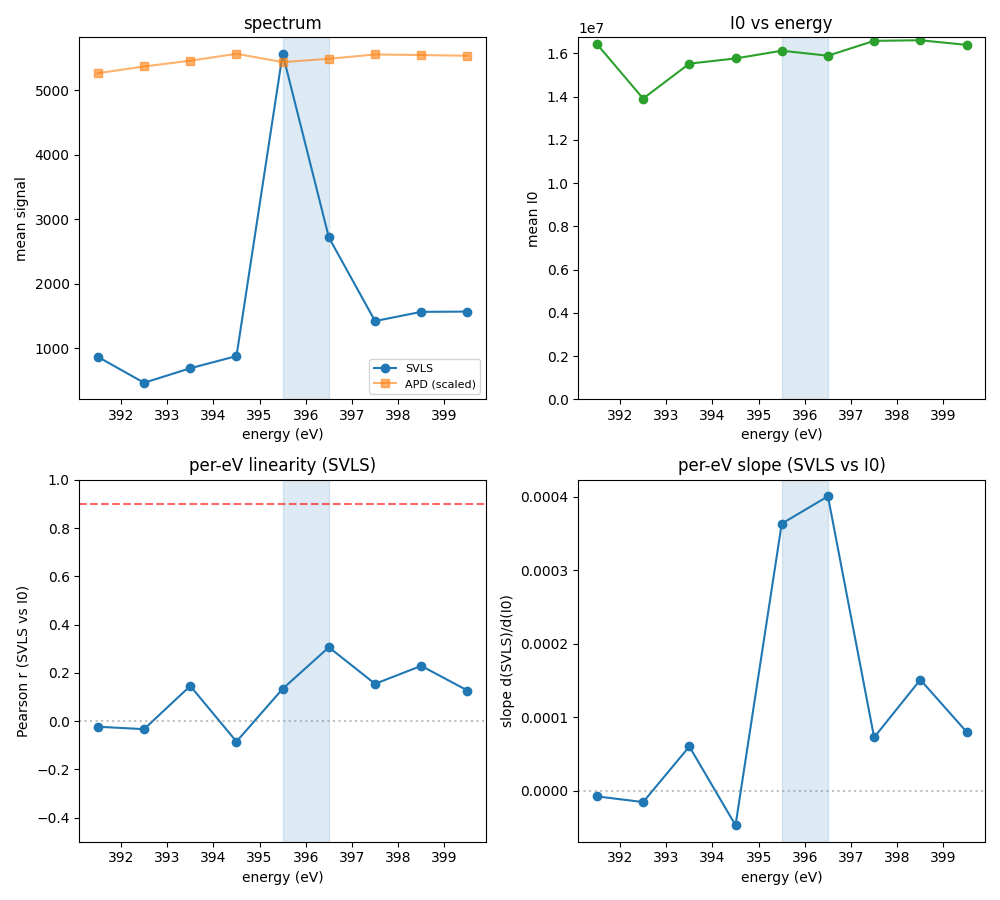

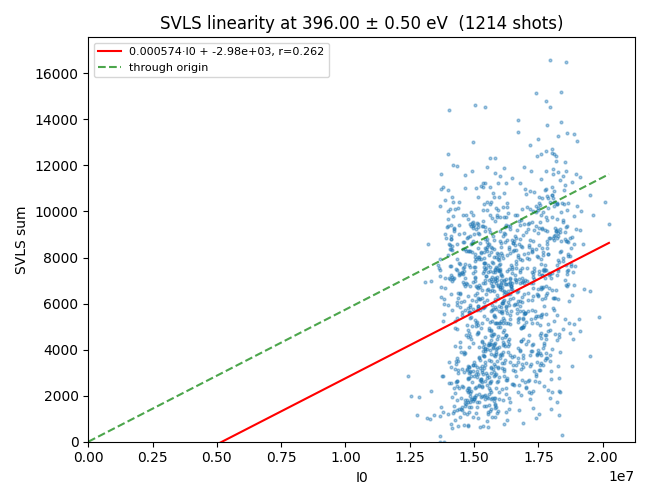

In [26]:
# ============================================================
#  CHOOSE THE ENERGY TO INSPECT
# ============================================================
E_focus = 396     # eV, or None → auto-pick the best-populated bin
E_width = 1.0       # eV window centered on E_focus (1.0 = single bin; widen if sparse)
# ============================================================

sel = cmask
E, I0s, SV = energy_eV[sel], I0_i[sel], svls_sum[sel]
AP = apd_i[sel] if apd_i is not None else None

ebins = np.arange(np.floor(np.nanmin(E)), np.ceil(np.nanmax(E)) + 1, 1.0)
ecen  = 0.5 * (ebins[:-1] + ebins[1:])
idx   = np.digitize(E, ebins)

n_per = np.array([(idx == i+1).sum() for i in range(len(ecen))])
def binstat(arr, f):
    return np.array([f(arr[idx==i+1]) if n_per[i] > 5 else np.nan for i in range(len(ecen))])
sv_mean, i0_mean = binstat(SV, np.nanmean), binstat(I0s, np.nanmean)
ap_mean = binstat(AP, np.nanmean) if AP is not None else None

def fit_bin_sv(i):
    m = idx == i+1
    if m.sum() < 10: return np.nan, np.nan
    s, _ = np.polyfit(I0s[m], SV[m], 1)
    return s, np.corrcoef(I0s[m], SV[m])[0, 1]
slope_E_sv, r_E_sv = np.array([fit_bin_sv(i) for i in range(len(ecen))]).T

# 4-panel diagnostic
fig, ax = plt.subplots(2, 2, figsize=(10, 9))
ax[0,0].plot(ecen, sv_mean, 'o-', label='SVLS')
if ap_mean is not None:
    ax[0,0].plot(ecen, ap_mean/np.nanmax(ap_mean)*np.nanmax(sv_mean),
                 's-', alpha=0.6, label='APD (scaled)')
ax[0,0].set_xlabel('energy (eV)'); ax[0,0].set_ylabel('mean signal')
ax[0,0].set_title('spectrum'); ax[0,0].legend(fontsize=8)

ax[0,1].plot(ecen, i0_mean, 'o-', color='tab:green'); ax[0,1].set_ylim(bottom=0)
ax[0,1].set_xlabel('energy (eV)'); ax[0,1].set_ylabel('mean I0')
ax[0,1].set_title('I0 vs energy')

ax[1,0].plot(ecen, r_E_sv, 'o-')
ax[1,0].axhline(0.9, ls='--', color='r', alpha=0.6)
ax[1,0].axhline(0,   ls=':',  color='gray', alpha=0.5)
ax[1,0].set_ylim(-0.5, 1)
ax[1,0].set_xlabel('energy (eV)'); ax[1,0].set_ylabel('Pearson r (SVLS vs I0)')
ax[1,0].set_title('per-eV linearity (SVLS)')

ax[1,1].plot(ecen, slope_E_sv, 'o-'); ax[1,1].axhline(0, ls=':', color='gray', alpha=0.5)
ax[1,1].set_xlabel('energy (eV)'); ax[1,1].set_ylabel('slope d(SVLS)/d(I0)')
ax[1,1].set_title('per-eV slope (SVLS vs I0)')

# highlight focus window across all panels
if E_focus is not None:
    for a in ax.ravel():
        a.axvspan(E_focus - E_width/2, E_focus + E_width/2, alpha=0.15, color='tab:blue')
plt.tight_layout(); plt.show()

# ---- focus window for the scatter ----
if E_focus is None:
    ib = int(np.nanargmax(n_per))
    m_focus = idx == ib+1
    focus_label = f'{ecen[ib]:.1f} eV (auto, best-populated bin)'
else:
    m_focus = (E >= E_focus - E_width/2) & (E < E_focus + E_width/2)
    focus_label = f'{E_focus:.2f} ± {E_width/2:.2f} eV'

n_focus = int(m_focus.sum())
if n_focus < 10:
    print(f'⚠ only {n_focus} shots in focus window — fit unreliable. '
          f'Widen E_width or pick a different E_focus.')
else:
    s, b = np.polyfit(I0s[m_focus], SV[m_focus], 1)
    r    = np.corrcoef(I0s[m_focus], SV[m_focus])[0, 1]
    fig, axx = plt.subplots(figsize=(6.5, 5))
    axx.plot(I0s[m_focus], SV[m_focus], '.', ms=4, alpha=0.4)
    xx = np.linspace(0, I0s[m_focus].max(), 100)
    axx.plot(xx, s*xx + b, 'r-', label=f'{s:.3g}·I0 + {b:.3g}, r={r:.3f}')
    axx.plot(xx, s*xx,     'g--', alpha=0.7, label='through origin')
    axx.set_xlim(0); axx.set_ylim(0); axx.set_xlabel('I0'); axx.set_ylabel('SVLS sum')
    axx.set_title(f'SVLS linearity at {focus_label}  ({n_focus} shots)')
    axx.legend(fontsize=8); plt.tight_layout(); plt.show()

/lscratch/amke/tmp/ipykernel_942371/4015045110.py:29: RuntimeWarning: invalid value encountered in divide
  ax[1, col].plot(ecen, arr / np.nanmean(arr), 'o-', alpha=0.75, label=f'ch{c}')


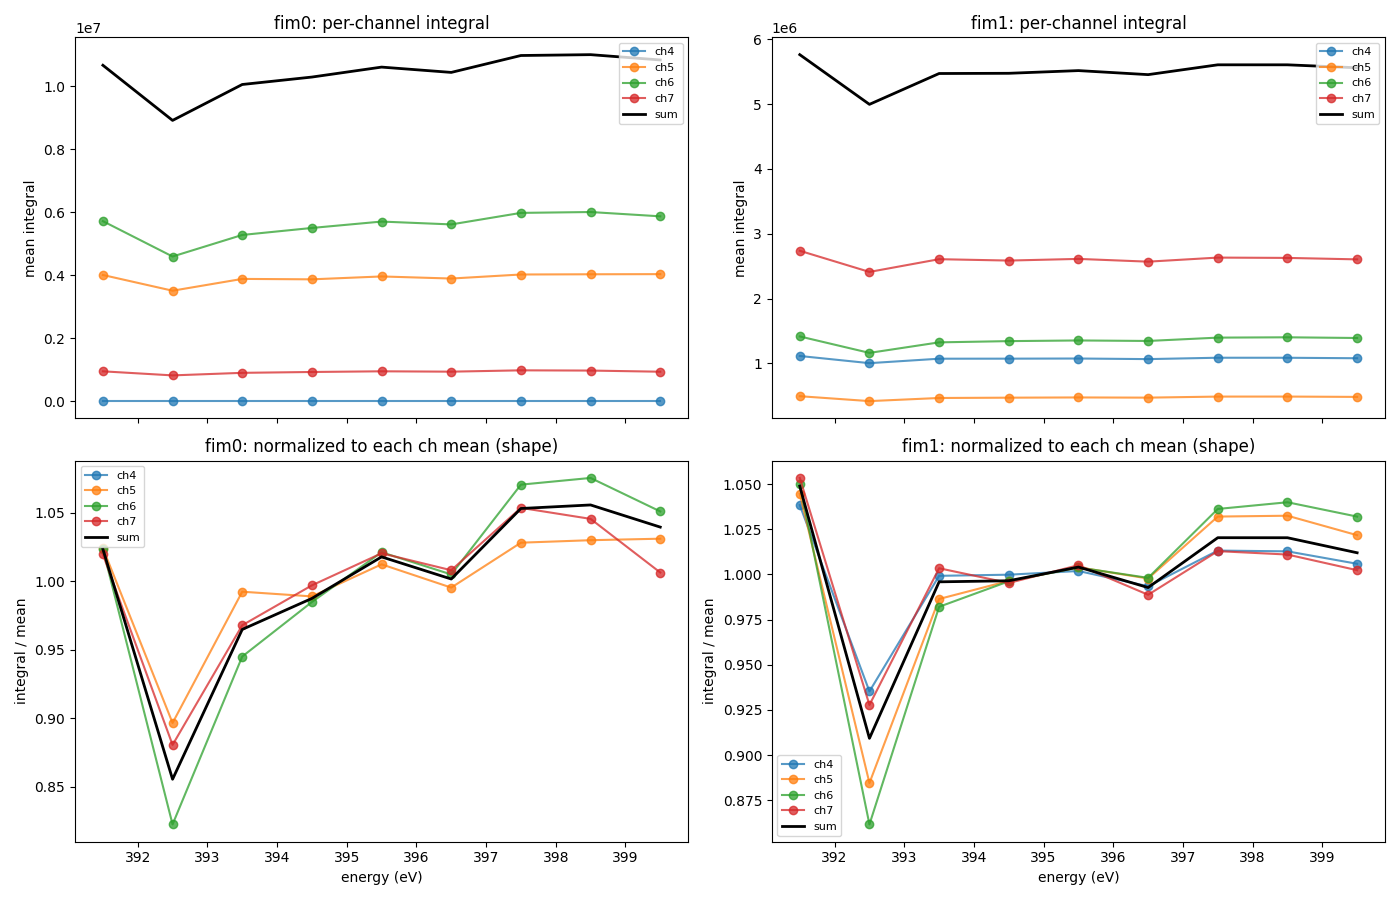

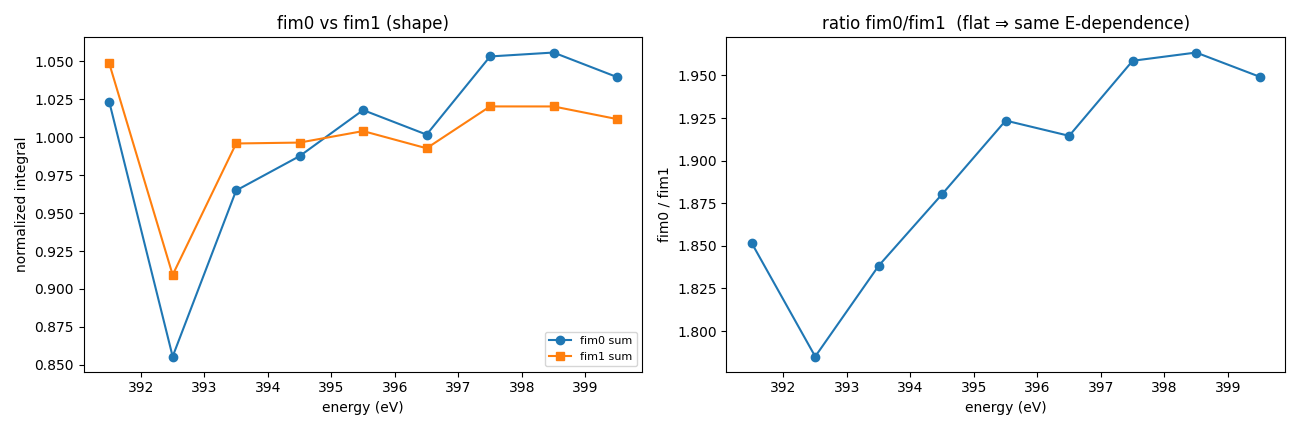

In [21]:
sel = cmask
E   = energy_eV[sel]
ebins = np.arange(np.floor(np.nanmin(E)), np.ceil(np.nanmax(E)) + 1, 1.0)
ecen  = 0.5 * (ebins[:-1] + ebins[1:])
idx   = np.digitize(E, ebins)
n_per = np.array([(idx==i+1).sum() for i in range(len(ecen))])

def per_chan_integral(wf, ch_idx, roi_pair, bg_roi):
    bg  = wf[:, ch_idx, bg_roi[0]:bg_roi[1]].mean(axis=-1, keepdims=True)
    bgf = wf[:, ch_idx, :] - bg
    return np.nansum(np.abs(bgf[:, roi_pair[0]:roi_pair[1]]), axis=1)

def binmean(arr_sel):
    return np.array([np.nanmean(arr_sel[idx==i+1]) if n_per[i] > 5 else np.nan
                     for i in range(len(ecen))])

fim_data = []
for det_name, wf, det_cfg in [('fim0', fim0_wf, fim0_cfg), ('fim1', fim1_wf, fim1_cfg)]:
    chans, rois, bgr = det_cfg['channels'], det_cfg['roi'], det_cfg['bg_roi']
    per_chan = {c: binmean(per_chan_integral(wf, c-1, rois[i], bgr)[sel])
                for i, c in enumerate(chans)}
    fim_data.append((det_name, per_chan, sum(per_chan.values())))

# top row: raw per-channel; bottom row: normalized to channel mean to compare shapes
fig, ax = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for col, (det_name, per_chan, total) in enumerate(fim_data):
    for c, arr in per_chan.items():
        ax[0, col].plot(ecen, arr, 'o-', alpha=0.75, label=f'ch{c}')
        ax[1, col].plot(ecen, arr / np.nanmean(arr), 'o-', alpha=0.75, label=f'ch{c}')
    ax[0, col].plot(ecen, total, 'k-', lw=2, label='sum')
    ax[1, col].plot(ecen, total / np.nanmean(total), 'k-', lw=2, label='sum')
    ax[0, col].set_title(f'{det_name}: per-channel integral'); ax[0, col].set_ylabel('mean integral')
    ax[1, col].set_title(f'{det_name}: normalized to each ch mean (shape)'); ax[1, col].set_ylabel('integral / mean')
    ax[1, col].set_xlabel('energy (eV)')
    ax[0, col].legend(fontsize=8); ax[1, col].legend(fontsize=8)
plt.tight_layout(); plt.show()

# fim0-vs-fim1 cross-check: same energy dependence ⇒ the structure is real beam I0, not detector
fim0_tot, fim1_tot = fim_data[0][2], fim_data[1][2]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].plot(ecen, fim0_tot/np.nanmean(fim0_tot), 'o-', label='fim0 sum')
ax[0].plot(ecen, fim1_tot/np.nanmean(fim1_tot), 's-', label='fim1 sum')
ax[0].set_xlabel('energy (eV)'); ax[0].set_ylabel('normalized integral')
ax[0].set_title('fim0 vs fim1 (shape)'); ax[0].legend(fontsize=8)
ax[1].plot(ecen, fim0_tot/fim1_tot, 'o-')
ax[1].set_xlabel('energy (eV)'); ax[1].set_ylabel('fim0 / fim1')
ax[1].set_title('ratio fim0/fim1  (flat ⇒ same E-dependence)')
plt.tight_layout(); plt.show()

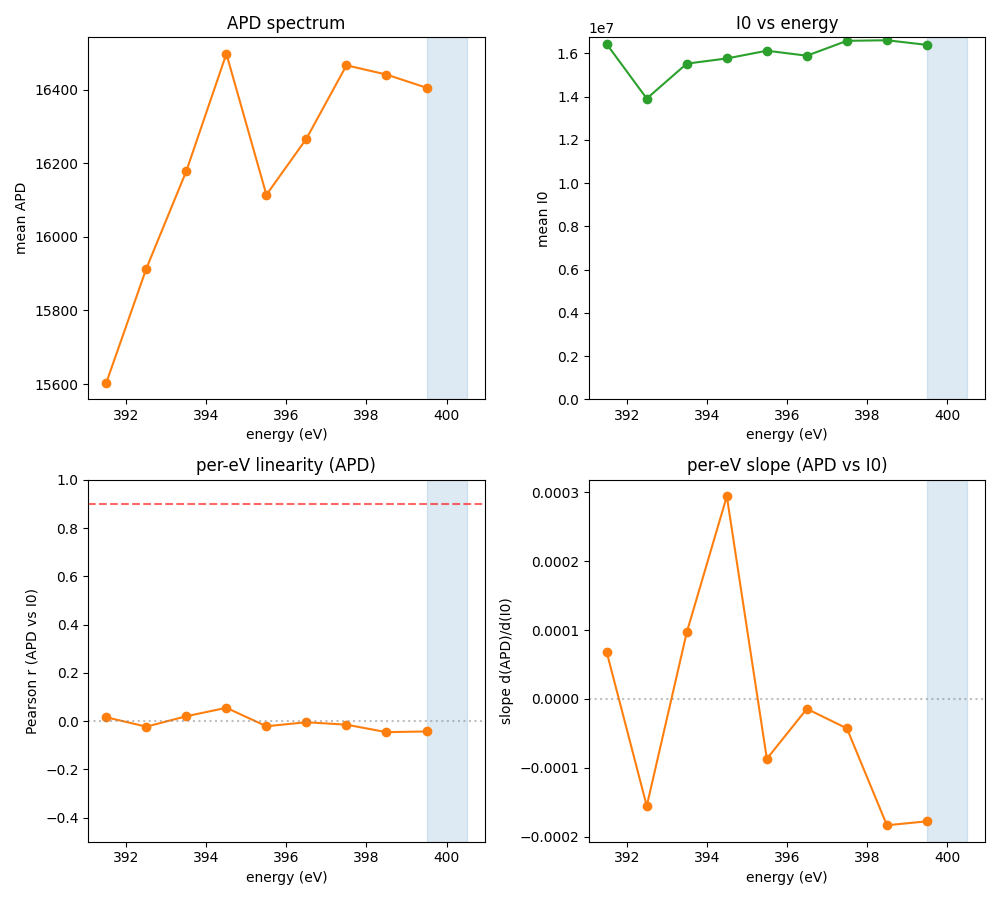

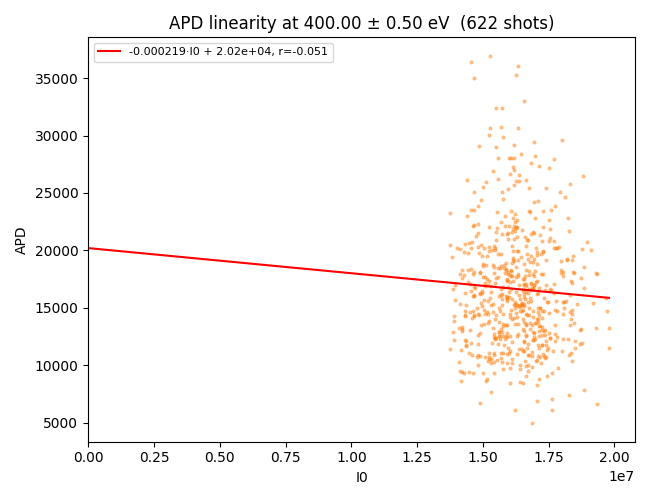

In [24]:
# ============================================================
#  CHOOSE THE ENERGY TO INSPECT
# ============================================================
E_focus = 400     # eV, or None → auto-pick the best-populated bin
E_width = 1.0       # eV window centered on E_focus (1.0 = single bin; widen if sparse)
# ============================================================

sel = cmask
E, I0s, AP = energy_eV[sel], I0_i[sel], apd_i[sel]

ebins = np.arange(np.floor(np.nanmin(E)), np.ceil(np.nanmax(E)) + 1, 1.0)
ecen  = 0.5 * (ebins[:-1] + ebins[1:])
idx   = np.digitize(E, ebins)

n_per = np.array([(idx == i+1).sum() for i in range(len(ecen))])
def binstat(arr, f):
    return np.array([f(arr[idx==i+1]) if n_per[i] > 5 else np.nan for i in range(len(ecen))])
ap_mean, i0_mean = binstat(AP, np.nanmean), binstat(I0s, np.nanmean)

def fit_bin_ap(i):
    m = idx == i+1
    if m.sum() < 10: return np.nan, np.nan
    s, _ = np.polyfit(I0s[m], AP[m], 1)
    return s, np.corrcoef(I0s[m], AP[m])[0, 1]
slope_E_ap, r_E_ap = np.array([fit_bin_ap(i) for i in range(len(ecen))]).T

# 4-panel diagnostic
fig, ax = plt.subplots(2, 2, figsize=(10, 9))
ax[0,0].plot(ecen, ap_mean, 'o-', color='tab:orange')
ax[0,0].set_xlabel('energy (eV)'); ax[0,0].set_ylabel('mean APD'); ax[0,0].set_title('APD spectrum')
ax[0,1].plot(ecen, i0_mean, 'o-', color='tab:green'); ax[0,1].set_ylim(bottom=0)
ax[0,1].set_xlabel('energy (eV)'); ax[0,1].set_ylabel('mean I0'); ax[0,1].set_title('I0 vs energy')
ax[1,0].plot(ecen, r_E_ap, 'o-', color='tab:orange')
ax[1,0].axhline(0.9, ls='--', color='r', alpha=0.6); ax[1,0].axhline(0, ls=':', color='gray', alpha=0.5)
ax[1,0].set_ylim(-0.5, 1)
ax[1,0].set_xlabel('energy (eV)'); ax[1,0].set_ylabel('Pearson r (APD vs I0)')
ax[1,0].set_title('per-eV linearity (APD)')
ax[1,1].plot(ecen, slope_E_ap, 'o-', color='tab:orange'); ax[1,1].axhline(0, ls=':', color='gray', alpha=0.5)
ax[1,1].set_xlabel('energy (eV)'); ax[1,1].set_ylabel('slope d(APD)/d(I0)')
ax[1,1].set_title('per-eV slope (APD vs I0)')

# highlight the focus window across all panels
if E_focus is not None:
    for a in ax.ravel():
        a.axvspan(E_focus - E_width/2, E_focus + E_width/2, alpha=0.15, color='tab:blue')
plt.tight_layout(); plt.show()

# ---- focus window for the scatter ----
if E_focus is None:
    ib = int(np.nanargmax(n_per))
    m_focus = idx == ib+1
    focus_label = f'{ecen[ib]:.1f} eV (auto, best-populated bin)'
else:
    m_focus = (E >= E_focus - E_width/2) & (E < E_focus + E_width/2)
    focus_label = f'{E_focus:.2f} ± {E_width/2:.2f} eV'

n_focus = int(m_focus.sum())
if n_focus < 10:
    print(f'⚠ only {n_focus} shots in focus window — fit unreliable. Widen E_width or pick a different E_focus.')
else:
    s, b = np.polyfit(I0s[m_focus], AP[m_focus], 1)
    r    = np.corrcoef(I0s[m_focus], AP[m_focus])[0, 1]
    fig, axx = plt.subplots(figsize=(6.5, 5))
    axx.plot(I0s[m_focus], AP[m_focus], '.', ms=4, alpha=0.4, color='tab:orange')
    xx = np.linspace(0, I0s[m_focus].max(), 100)
    axx.plot(xx, s*xx + b, 'r-', label=f'{s:.3g}·I0 + {b:.3g}, r={r:.3f}')
    axx.set_xlim(0); axx.set_xlabel('I0'); axx.set_ylabel('APD')
    axx.set_title(f'APD linearity at {focus_label}  ({n_focus} shots)')
    axx.legend(fontsize=8); plt.tight_layout(); plt.show()

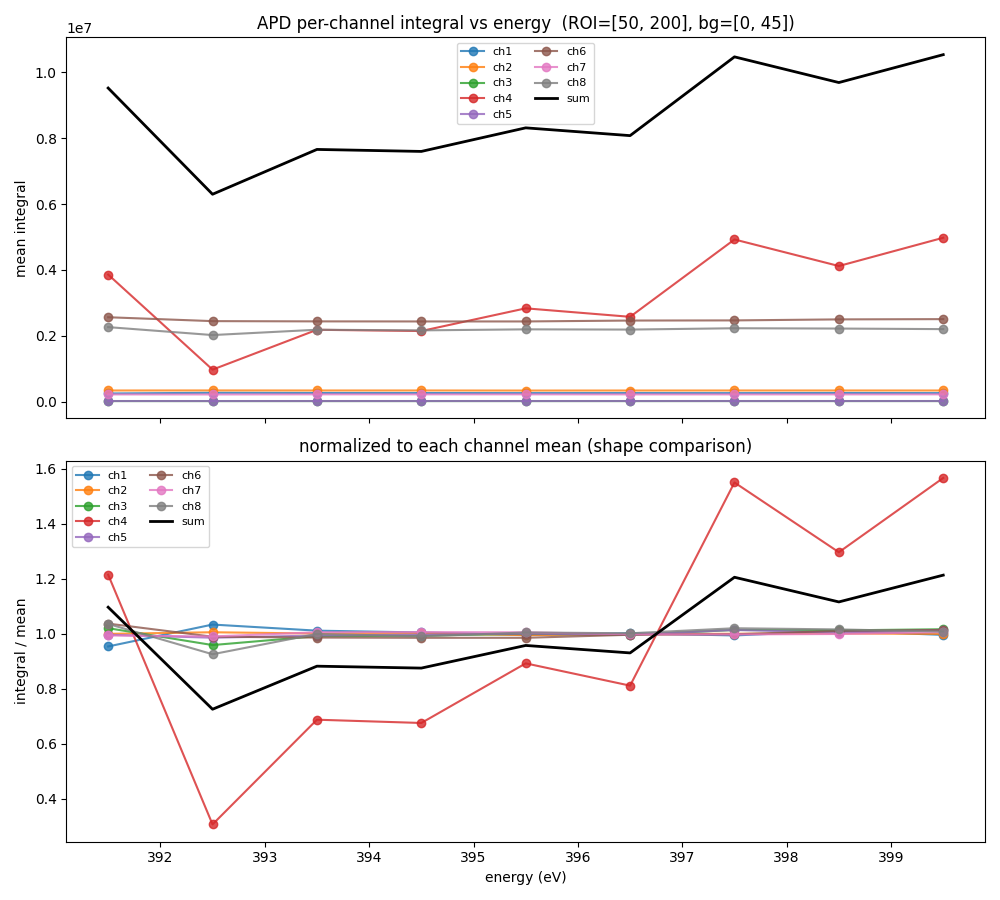

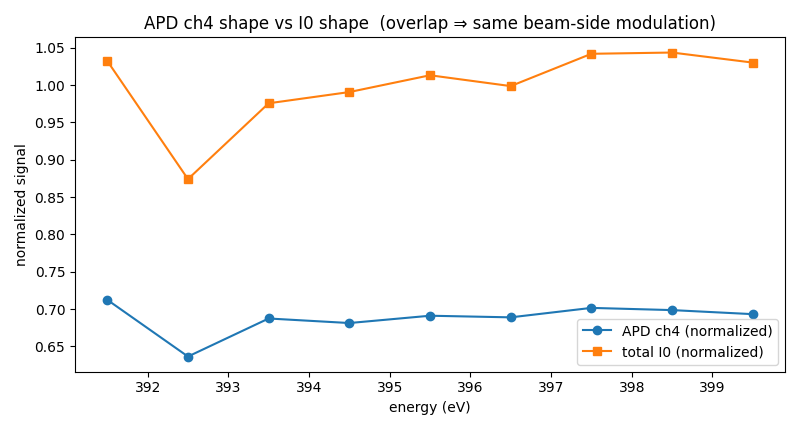

In [27]:
sel = cmask
E   = energy_eV[sel]

ebins = np.arange(np.floor(np.nanmin(E)), np.ceil(np.nanmax(E)) + 1, 1.0)
ecen  = 0.5 * (ebins[:-1] + ebins[1:])
idx   = np.digitize(E, ebins)
n_per = np.array([(idx==i+1).sum() for i in range(len(ecen))])

def binmean(arr_sel):
    return np.array([np.nanmean(arr_sel[idx==i+1]) if n_per[i] > 5 else np.nan
                     for i in range(len(ecen))])

# common wide ROI/bg for all APD channels (bypasses the cut-down cfg['apd'])
common_roi = [50, 200]
common_bg  = [0, 45]
chans_to_show = list(range(1, apd_wf.shape[1] + 1))   # all channels in the data array, 1-indexed

per_chan = {}
for c in chans_to_show:
    ch  = c - 1
    bg  = apd_wf[:, ch, common_bg[0]:common_bg[1]].mean(-1, keepdims=True)
    bgf = apd_wf[:, ch, :] - bg
    full = np.nansum(np.abs(bgf[:, common_roi[0]:common_roi[1]]), axis=1)
    per_chan[c] = binmean(full[sel])
total = sum(per_chan.values())

fig, ax = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
for c, arr in per_chan.items():
    ax[0].plot(ecen, arr, 'o-', alpha=0.8, label=f'ch{c}')
    if np.isfinite(np.nanmean(arr)) and np.nanmean(arr) > 0:
        ax[1].plot(ecen, arr / np.nanmean(arr), 'o-', alpha=0.8, label=f'ch{c}')
ax[0].plot(ecen, total, 'k-', lw=2, label='sum')
ax[1].plot(ecen, total / np.nanmean(total), 'k-', lw=2, label='sum')
ax[0].set_title(f'APD per-channel integral vs energy  (ROI={common_roi}, bg={common_bg})')
ax[0].set_ylabel('mean integral')
ax[1].set_title('normalized to each channel mean (shape comparison)')
ax[1].set_ylabel('integral / mean'); ax[1].set_xlabel('energy (eV)')
ax[0].legend(fontsize=8, ncol=2); ax[1].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

# bonus: does APD ch4's energy dependence match the I0 hump, or something else?
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(ecen, per_chan[8]/np.nanmean(per_chan[4]), 'o-', label='APD ch4 (normalized)')
i0_mean = binmean(I0_i[sel])
ax.plot(ecen, i0_mean/np.nanmean(i0_mean), 's-', label='total I0 (normalized)')
ax.set_xlabel('energy (eV)'); ax.set_ylabel('normalized signal')
ax.set_title('APD ch4 shape vs I0 shape  (overlap ⇒ same beam-side modulation)')
ax.legend(); plt.tight_layout(); plt.show()

In [28]:
run = runs[0]

fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'

data = SmallData(fname,fyaml)
proc = Reduced(fname,bgname,fyaml,bgyaml)
# bg = SmallData(bgname, bgyaml)

NameError: name 'base_folder' is not defined

In [7]:
proc.data.scantype

'mono_fly'

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(15,3))
ax.scatter(np.arange(len(data.integrating.axis_svls.mono))[data.integrating.axis_svls.eventcodes[:,272]==1],data.integrating.axis_svls.mono[data.integrating.axis_svls.eventcodes[:,272]==1],color='r',s=2,label='laser on')
ax.scatter(np.arange(len(data.integrating.axis_svls.mono))[data.integrating.axis_svls.eventcodes[:,273]==1],data.integrating.axis_svls.mono[data.integrating.axis_svls.eventcodes[:,273]==1],color='k',s=2,label='laser off')
ax.legend()
ax.set_xlim([0,len(data.integrating.axis_svls.mono)])
# fig.savefig('figs/mono_move_onoff.png',dpi=200,bbox_inches='tight')


In [ ]:
for run in runs:
    fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
    red = Reduced(fname,bgname,fyaml,bgyaml, save=True)



avg=avg_data(runs,proc_folder)

In [ ]:
red.data.integrating.axis_svls.mono.max()

In [ ]:
fig,ax=plt.subplots()
ax.plot(np.nansum(red.data.integrating.axis_svls.full_area,axis=0),'k',label='data')
ax.plot(np.nansum(red.bg.integrating.axis_svls.full_area,axis=0),'r',alpha=0.5,label='background')
ax.legend()
# ax.plot(np.nansum(red.proc,axis=0),'k')
# ax.plot(np.nansum(red.proc.svls,axis=0),'r')

In [ ]:
fig,ax=plt.subplots(1,1)
ax.plot(red.scanvar_on,np.sum(red.axis_svls_on_mean,1)-np.sum(red.axis_svls_off_mean,1))
ax.plot(red.scanvar_off,np.sum(red.axis_svls_off_mean,1))
# ax.set_xlim([red.scanvar_on.min(),red.scanvar_on.max()])

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(9,3),sharex=True,sharey=True)
ax[0].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_off_sum']))
ddat=np.nanmax(np.abs(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='RdBu')
ax[0].set_xlim([avg['scanvar_off'].min(),avg['scanvar_off'].max()])

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

# if emi_calib == []:
#     if data.runinfo == 'mono':
emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
            dat=avg['axis_svls_sum'], 
            mono = avg['scanvar'], 
            calib=emi_calib, 
                points = points)
#     else:
#         print('need mono scan to calibrate using emission axis')
# else:
#     emi,calib =pixel2emi(np.arange(avg['axis_svls_sum'].shape[1]), mono=[],
#                     dat=avg['axis_svls_sum'], 
#                     calib=emi_calib) 
                    
# if data.runinfo == 'mono':
mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
# else:
#     E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

if emi_calib == []:
    if data.scantype == 'mono':
        emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    mono = avg['scanvar_on'], 
                    calib=emi_calib, 
                    points = points)
    else:
        print('need mono scan to calibrate using emission axis')
else:
    emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    calib=emi_calib) 
                    
if data.scantype == 'mono':
    mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
    mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_off'],emi,avg['axis_svls_off_sum'],step=0.1)
else:
    E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

In [ ]:
fig,ax=plt.subplots(1,3)
ax[0].pcolor(avg['scanvar_on'],emi,avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))



In [ ]:

fig,ax=plt.subplots(1,3)
ax[0].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_off_mean))
ax[1].pcolor(red.scanvar_off,np.arange(red.axis_svls_off_mean.shape[1]),red.axis_svls_off_mean.T,cmap='terrain_r',vmin=0,vmax=np.max(red.axis_svls_off_mean))
ax[2].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T-red.axis_svls_off_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_on_mean-red.axis_svls_off_mean))


In [ ]:
data.singleshot.fim_0.full_area
bg_roi=[0,50]
bg = np.mean(data.singleshot.fim_0.full_area[...,bg_roi[0]:bg_roi[1]],axis= -1)
bgf = data.singleshot.fim_0.full_area - bg[...,np.newaxis]

In [ ]:
fim_roi=[60,70]

fim_proc =subtract_bg(data.singleshot.fim_0.full_area,[0,50])
fim_wf_avs = np.nanmean(fim_proc,axis = 0)
# fim = np.sum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = (1,2))

# fim = np.nansum(fim_proc[:,:,fim_roi[0]:fim_roi[1]],axis = (1,2))

fim_sum_all = np.nansum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = 2)

In [6]:
# run=76
# fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
# test = h5py.File(fname, 'r')
#run=142
#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
run=84
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
test1 = h5py.File(fname, 'r')
test1['intg']['axis_svls'].keys()
# test1['scan']['lxt_ttc']

<KeysViewHDF5 ['c_piranha_sum_full_area', 'count', 'crix_w8_sum_base_0', 'crix_w8_sum_base_1', 'crix_w8_sum_base_2', 'crix_w8_sum_base_3', 'crix_w8_sum_base_4', 'crix_w8_sum_base_5', 'crix_w8_sum_base_6', 'crix_w8_sum_base_7', 'crix_w8_sum_base_all', 'crix_w8_sum_integral_0', 'crix_w8_sum_integral_1', 'crix_w8_sum_integral_2', 'crix_w8_sum_integral_3', 'crix_w8_sum_integral_4', 'crix_w8_sum_integral_5', 'crix_w8_sum_integral_6', 'crix_w8_sum_integral_7', 'crix_w8_sum_integral_all', 'crix_w8_sum_intensity', 'crix_w8_sum_itrigCount', 'crix_w8_sum_posX', 'crix_w8_sum_posY', 'crix_w8_sum_ptrigCount', 'det_crix_w8_sum_full_area', 'det_crix_w8_sum_wfintegrate', 'det_rix_fim0_sum_full_area', 'det_rix_fim0_sum_wfintegrate', 'det_rix_fim1_sum_full_area', 'det_rix_fim1_sum_wfintegrate', 'droplet_dense_curve_corr_corrected_image', 'droplet_dense_curve_corr_pj_ax_1_data', 'droplet_nDroplets', 'droplet_nDroplets_all', 'gmd_sum_RMS_E1', 'gmd_sum_RMS_E1_sevr', 'gmd_sum_milliJoulesPerPulse', 'gmd_sum_

In [ ]:
premirror = get_premirror_pitch(red.data.epics['MONO_premirror_pitch'][:])
hrencoder = red.data.integrating.andor_vls.mono_encoder
hr_pitch = hrencoder_to_pitch(hrencoder, red.data.yaml['mono_calib'])
hr_energy = mono_energy(hr_pitch,premirror)
hr_energy

In [ ]:
testfile = h5py.File('testsave.h5','w')
keys = vars(red)
avg = {}
for key in keys:
    avg[key] = np.zeros(testfile[key].shape)

for dat in keys:
    if 'on' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])
    elif 'off' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])


testfile.close()

In [ ]:
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    h5dump(tmp)


In [4]:

import dask.array as da
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
exp = 'rix101331225'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0061.h5'


with h5py.File(fname,'r') as file:
    print(file['intg']['axis_svls'].keys())
    test=da.from_array(file['intg']['axis_svls']['det_crix_w8_sum_full_area'], chunks = 'auto')
    # ax.plot(np.nanmean(file['intg']['axis_svls']['curve_corr_corrected_image'],axis=0))
    # fh = h5py.File(fname, 'r')
    test_ims_thresh = file['intg/axis_svls/curve_corr_corrected_image'][:20,:][...]
    test_los_thresh = file['intg/axis_svls/curve_corr_pj_ax_1_data'][:,:][...]
plt.figure()
plt.subplot(211)
plt.plot(np.nanmean(test_los_thresh,axis =0),label = 'curve_corr_pj_ax_1_data')
plt.legend()
plt.subplot(212)
plt.plot(np.nanmean(test_ims_thresh,axis =(0,2)),label = 'lineout from curve_corr_corrected_image')
plt.xlabel('pixel')
# Plt.legend()
plt.show()

<KeysViewHDF5 ['count', 'crix_w8_sum_base_0', 'crix_w8_sum_base_1', 'crix_w8_sum_base_2', 'crix_w8_sum_base_3', 'crix_w8_sum_base_4', 'crix_w8_sum_base_5', 'crix_w8_sum_base_6', 'crix_w8_sum_base_7', 'crix_w8_sum_base_all', 'crix_w8_sum_integral_0', 'crix_w8_sum_integral_1', 'crix_w8_sum_integral_2', 'crix_w8_sum_integral_3', 'crix_w8_sum_integral_4', 'crix_w8_sum_integral_5', 'crix_w8_sum_integral_6', 'crix_w8_sum_integral_7', 'crix_w8_sum_integral_all', 'crix_w8_sum_intensity', 'crix_w8_sum_itrigCount', 'crix_w8_sum_posX', 'crix_w8_sum_posY', 'crix_w8_sum_ptrigCount', 'det_crix_w8_sum_full_area', 'det_crix_w8_sum_wfintegrate', 'det_rix_fim0_sum_full_area', 'det_rix_fim0_sum_wfintegrate', 'det_rix_fim1_sum_full_area', 'det_rix_fim1_sum_wfintegrate', 'droplet_dense_curve_corr_corrected_image', 'droplet_nDroplets', 'droplet_nDroplets_all', 'gmd_sum_RMS_E1', 'gmd_sum_RMS_E1_sevr', 'gmd_sum_milliJoulesPerPulse', 'gmd_sum_milliJoulesPerPulse_sevr', 'lightStatus_sum_laser', 'lightStatus_sum

KeyError: "Unable to synchronously open object (object 'curve_corr_corrected_image' doesn't exist)"

In [10]:
test_ims_thresh.sum()

0.0

In [10]:
run=106
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    print(tmp['intg']['axis_svls']['droplet_dense_curve_corr_pj_ax_1_data'].shape)

(3983, 796)


In [9]:
run=109
fname = f'./proc/Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    print(tmp['scantype'])

KeyError: "Unable to synchronously open object (object 'scantype' doesn't exist)"